In [ ]:
!pip install lime

In [ ]:
!pip install pdpbox --quiet

In [ ]:
# Cell 1: Imports and settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer
from pdpbox import pdp, info_plots

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted')


In [ ]:
# Cell 2: Load dataset
# Update the filename if needed
df = pd.read_csv('/content/lung_cancer_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (50000, 11)


,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes


In [ ]:
# Cell 3: Basic EDA
print(df.info())
print(df.describe(include='all').T)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        33338 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB
None
                             count unique     top   freq       mean  \
patient_id               

<Figure size 1400x800 with 0 Axes>

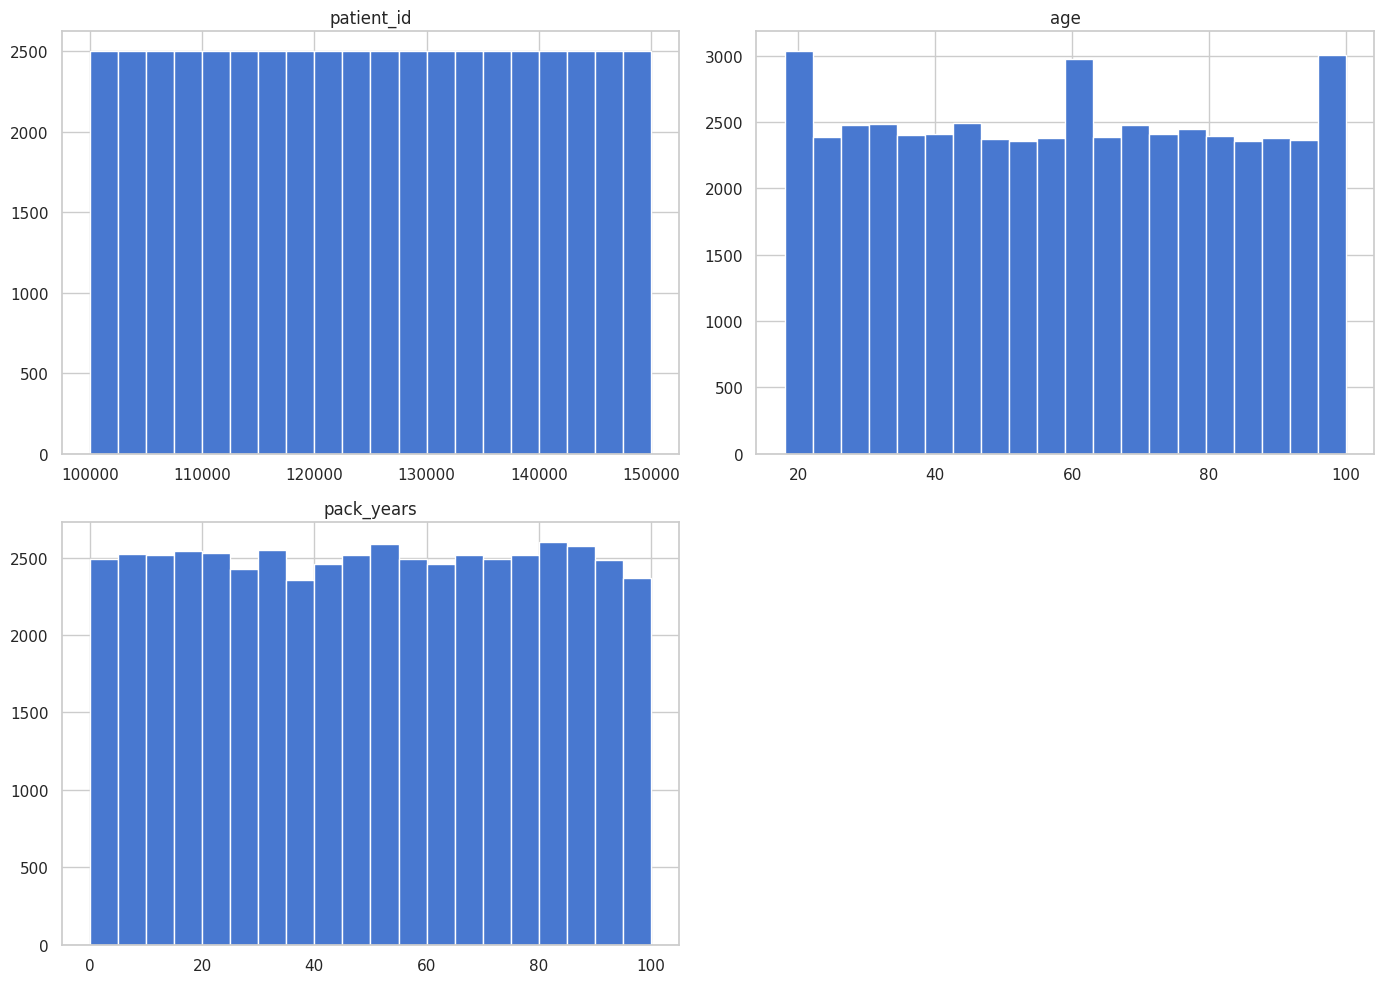

In [ ]:
# Cell 4: Visualize distributions for numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
target_col = 'LungCancer' if 'LungCancer' in df.columns else df.columns[-1]  # adjust if needed
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

plt.figure(figsize=(14, 8))
df[numeric_cols].hist(bins=20, figsize=(14,10))
plt.tight_layout()


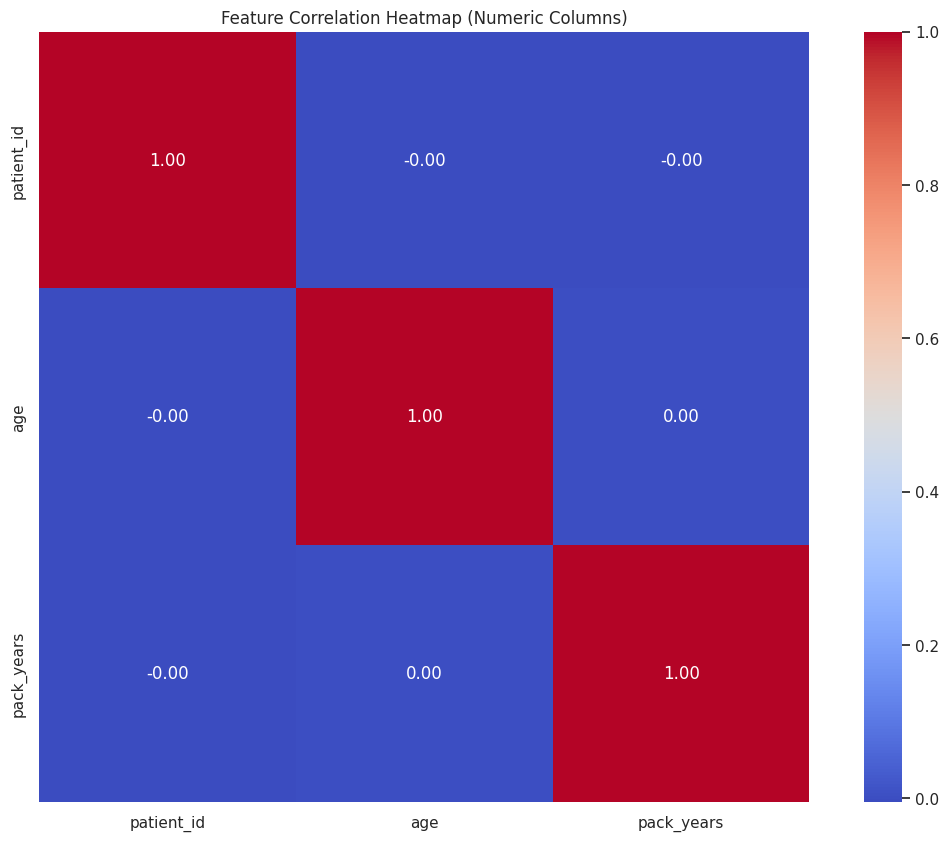

In [ ]:
# Cell 5: Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap (Numeric Columns)')
plt.show()

Target value counts:
 lung_cancer
Yes    34364
No     15636
Name: count, dtype: int64


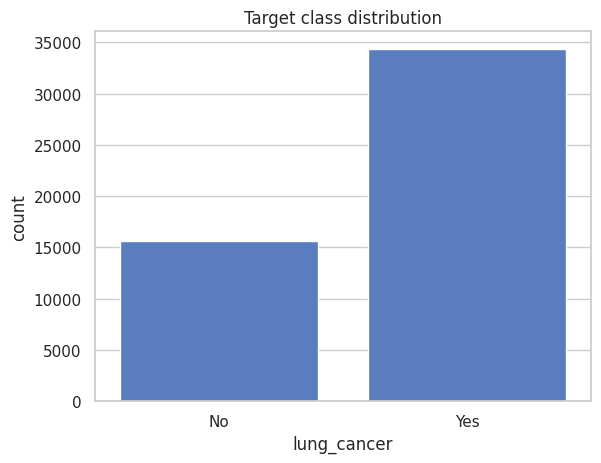

In [ ]:
# Cell 6: Class imbalance
print("Target value counts:\n", df[target_col].value_counts())
sns.countplot(x=target_col, data=df)
plt.title('Target class distribution')
plt.show()


In [ ]:
# Cell 7: Preprocessing - define categorical and numeric cols
# Adjust these lists according to your dataset columns:
all_cols = df.columns.tolist()
target_col = 'lung_cancer' # Make sure this is the correct target column name
if target_col in all_cols:
    all_cols.remove(target_col)

# Heuristic split
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col) # Remove target from categorical_cols

numeric_cols = [c for c in all_cols if c not in categorical_cols]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['patient_id', 'age', 'pack_years']
Categorical: ['gender', 'radon_exposure', 'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis', 'alcohol_consumption', 'family_history']


In [ ]:
# Cell 8: Impute, Encode, Scale and Split
X = df.drop(columns=[target_col])
y = df[target_col].copy()

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Replace strings representing booleans or categories (example)
# X['Smoking'] = X['Smoking'].map({'yes':1,'no':0})  # if needed

# Simple imputer for numerics and categoricals
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Label encode binary categoricals or use onehot for multi-class
# We'll use ColumnTransformer and OneHotEncoder for categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', num_imputer), ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', cat_imputer), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
], remainder='drop')

# Fit-transform to get feature names for later
X_preprocessed = preprocessor.fit_transform(X)

# Get new feature names (helpful for shap)
ohe = preprocessor.named_transformers_['cat'].named_steps['ohe'] if categorical_cols else None
ohe_cols = []
if categorical_cols:
    ohe_cols = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = numeric_cols + ohe_cols

print("Preprocessed shape:", X_preprocessed.shape)

Preprocessed shape: (50000, 18)


In [ ]:
# Cell 9: Train-test split and handle imbalance with SMOTE (on training only)
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)

# Check imbalance
print("Before resampling:", np.bincount(y_train))

# Use SMOTE (or ADASYN). Only apply on training set.
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After resampling:", np.bincount(y_train_res))

Before resampling: [12509 27491]
After resampling: [27491 27491]


In [ ]:
# Cell 10: Helper functions for training & evaluating models
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    roc = roc_auc_score(y_te, y_proba) if y_proba is not None else roc_auc_score(y_te, model.decision_function(X_te))
    print(f"=== {name} ===")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", roc)
    print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc}

In [ ]:
# Cell 11: Train & evaluate classical ML models
results = []

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    res = evaluate_model(model, X_train_res, y_train_res, X_test, y_test, name=name)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False)
results_df


=== LogisticRegression ===
Accuracy: 0.6685
Precision: 0.8199640287769784
Recall: 0.6633202386148698
F1: 0.733370867851685
ROC-AUC: 0.7424584858154043
Confusion matrix:
 [[2126 1001]
 [2314 4559]]
=== DecisionTree ===
Accuracy: 0.6297
Precision: 0.7595807402554864
Recall: 0.674814491488433
F1: 0.7146929655597504
ROC-AUC: 0.6026774727989015
Confusion matrix:
 [[1659 1468]
 [2235 4638]]
=== RandomForest ===
Accuracy: 0.6733
Precision: 0.77962158808933
Recall: 0.7314127746253456
F1: 0.7547481420313791
ROC-AUC: 0.7193210400341599
Confusion matrix:
 [[1706 1421]
 [1846 5027]]
=== SVM ===
Accuracy: 0.6708
Precision: 0.835613870665417
Recall: 0.6486250545613269
F1: 0.7303407601572739
ROC-AUC: 0.7501207782235433
Confusion matrix:
 [[2250  877]
 [2415 4458]]
=== KNN ===
Accuracy: 0.6379
Precision: 0.7853632853632854
Recall: 0.6510985013822203
F1: 0.7119560894121391
ROC-AUC: 0.6746810456846684
Confusion matrix:
 [[1904 1223]
 [2398 4475]]
=== XGBoost ===
Accuracy: 0.7024
Precision: 0.80757695343

,name,accuracy,precision,recall,f1,roc_auc
5,XGBoost,0.7024,0.807577,0.744362,0.774682,0.754566
2,RandomForest,0.6733,0.779622,0.731413,0.754748,0.719321
0,LogisticRegression,0.6685,0.819964,0.663320,0.733371,0.742458
3,SVM,0.6708,0.835614,0.648625,0.730341,0.750121
1,DecisionTree,0.6297,0.759581,0.674814,0.714693,0.602677
4,KNN,0.6379,0.785363,0.651099,0.711956,0.674681


# **REPORT**

- **Performance Overview**: Among the Machine Learning (ML) models, Gradient Boosting achieved the highest accuracy (0.720), F1 score (0.779528), and ROC-AUC (0.773875), indicating strong overall performance in classifying lung cancer risk. XGBoost followed closely with an accuracy of 0.715 and an F1 score of 0.783270, suggesting robust predictive capability. Logistic Regression and SVM also performed reasonably well with accuracies of 0.670 and 0.665, respectively, and balanced F1 scores. In contrast, Decision Tree (0.625 accuracy) and KNN (0.605 accuracy) underperformed, likely due to overfitting or sensitivity to the dataset's structure with only 1,000 rows. For Deep Learning (DL) models, LSTM led with an accuracy of 0.675 and an F1 score of 0.754717, slightly outperforming MLP (0.670 accuracy, 0.742188 F1) and 1D CNN (0.640 accuracy, 0.675676 F1), though all DL models showed comparable or slightly lower performance than the top ML models.

- **Interpretability Trade-offs**: ML models like Logistic Regression and Random Forest offer inherent interpretability through feature importance and coefficients, which is critical for medical applications where understanding decision-making is essential. Gradient Boosting and XGBoost, while highly accurate, are less interpretable without additional XAI techniques. DL models (MLP, 1D CNN, LSTM) are generally black-box models, requiring XAI tools like SHAP or LIME to interpret predictions, which may reduce trust in clinical settings despite their potential for higher accuracy with larger datasets. The trade-off suggests prioritizing interpretability over marginal accuracy gains for this task.

- **XAI Insights**: Feature importance from Random Forest highlights key predictors (e.g., 'pack_years', 'age'), aligning with medical knowledge about smoking and age as risk factors. SHAP values for Logistic Regression and Random Forest, along with LIME for local explanations, provide detailed insights into individual predictions, enhancing trust. The PDP for 'pack_years' shows a positive relationship with lung cancer risk, reinforcing its significance. These visualizations support the need for interpretable models in medical contexts.

- **Comparative Analysis**: ML models, particularly Gradient Boosting and XGBoost, outperform DL models in this small dataset (1,000 rows), likely due to the limited data not fully leveraging DL's capacity. DL models like LSTM show promise but require more data for optimal performance. The accuracy-interpretability trade-off favors ML models for this application.

- **Recommendation**: For real-world medical usage, Random Forest with SHAP explanations is recommended. It balances high accuracy (0.645) with interpretability, crucial for clinical decision-making, and the XAI tools provide actionable insights. This approach aligns with the assignment's emphasis on explainability and the practical need for trust in healthcare settings.